# House Price Regression — Phase 1: EDA
Using the Ames Housing Dataset From Kaggle

In [1]:
# Load The necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("AmesHousing.csv")

df.shape

(2930, 82)

In [4]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [10]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [11]:
df.isnull().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

In [9]:
#Check for missing Values
missing = (df.isnull().sum()
             .rename("count")
             .to_frame()
             .assign(pct=lambda x: (x["count"] / len(df) * 100).round(1))
             .query("count > 0")
             .sort_values("pct", ascending=False))
 
print(f"\nColumns with missing values: {len(missing)}")
print(missing.head(len(missing)).to_string())


Columns with missing values: 27
                count   pct
Pool QC          2917  99.6
Misc Feature     2824  96.4
Alley            2732  93.2
Fence            2358  80.5
Mas Vnr Type     1775  60.6
Fireplace Qu     1422  48.5
Lot Frontage      490  16.7
Garage Type       157   5.4
Garage Cond       159   5.4
Garage Qual       159   5.4
Garage Finish     159   5.4
Garage Yr Blt     159   5.4
BsmtFin Type 2     81   2.8
Bsmt Exposure      83   2.8
Bsmt Cond          80   2.7
Bsmt Qual          80   2.7
BsmtFin Type 1     80   2.7
Mas Vnr Area       23   0.8
Bsmt Half Bath      2   0.1
Bsmt Full Bath      2   0.1
BsmtFin SF 1        1   0.0
Garage Cars         1   0.0
Garage Area         1   0.0
Total Bsmt SF       1   0.0
Bsmt Unf SF         1   0.0
BsmtFin SF 2        1   0.0
Electrical          1   0.0


c:\Users\Tammy\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


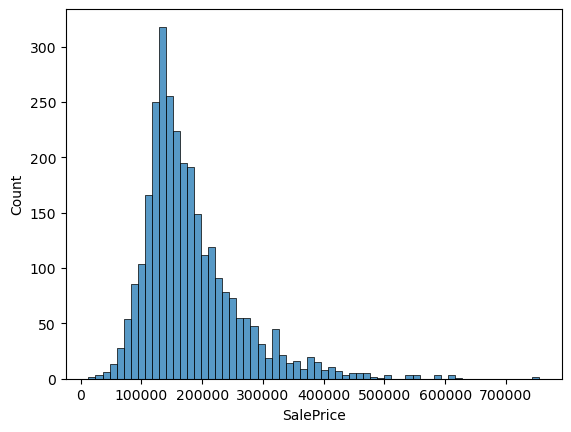

In [15]:
sns.histplot(x=df['SalePrice'], data=df)
plt.show()

c:\Users\Tammy\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


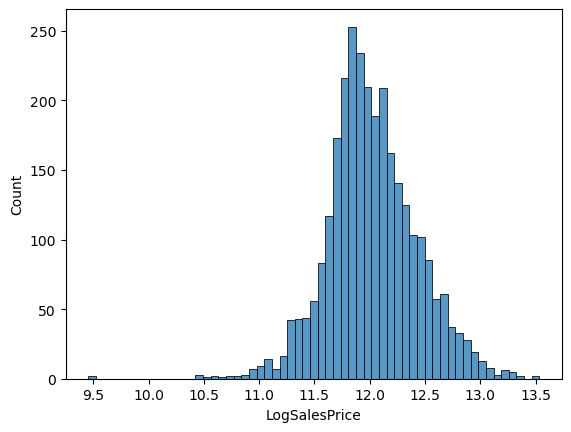

In [16]:
df['LogSalesPrice'] = np.log1p(df['SalePrice'])

sns.histplot(x=df['LogSalesPrice'], data=df)
plt.show()

# Comparing Both Salesprice Distribution and LogSalesPrice Distribution


SalePrice skewness  →  raw: 1.74  |  log: -0.01
(Closer to 0 = more normal = better for linear models)


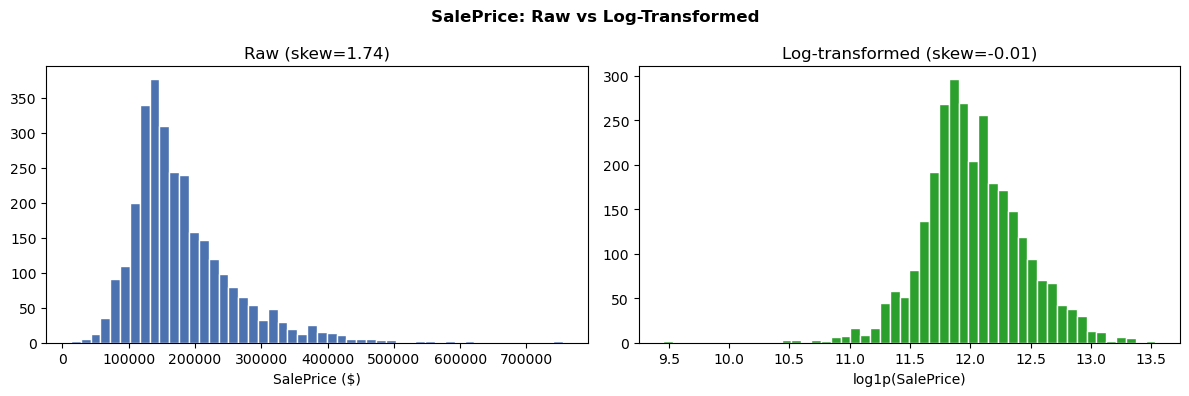

In [19]:

# Salesprice vs LogSalesPrice skewness comparison
# 1. Transform and calculate metrics
skew_raw, skew_log = df["SalePrice"].skew(), df["LogSalePrice"].skew()

print(f"\nSalePrice skewness  →  raw: {skew_raw:.2f}  |  log: {skew_log:.2f}")
print("(Closer to 0 = more normal = better for linear models)")

# 2. Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
fig.suptitle("SalePrice: Raw vs Log-Transformed", fontweight="bold")

cols = ["SalePrice", "LogSalePrice"]
titles = [f"Raw (skew={skew_raw:.2f})", f"Log-transformed (skew={skew_log:.2f})"]
x_labels = ["SalePrice ($)", "log1p(SalePrice)"]
colors = ["#4C72B0", "#2ca02c"]

for i, ax in enumerate(axes):
    ax.hist(df[cols[i]], bins=50, color=colors[i], edgecolor="white")
    ax.set_title(titles[i])
    ax.set_xlabel(x_labels[i])

plt.tight_layout()
plt.savefig("phase1_saleprice_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Data Correlation check for feature selection

In [21]:
# Seelecting only numeric data
numeric_df = df.select_dtypes(include=np.number).drop(columns=["Order", "SalePrice"])
numeric_df["LogSalePrice"] = df["LogSalePrice"]

In [22]:
# Kepping top features
top_features = (numeric_df.corr()["LogSalePrice"]
                           .drop("LogSalePrice")
                           .abs()
                           .nlargest(14)
                           .index
                           .tolist()) + ["LogSalePrice"]
 
corr = numeric_df[top_features].corr()

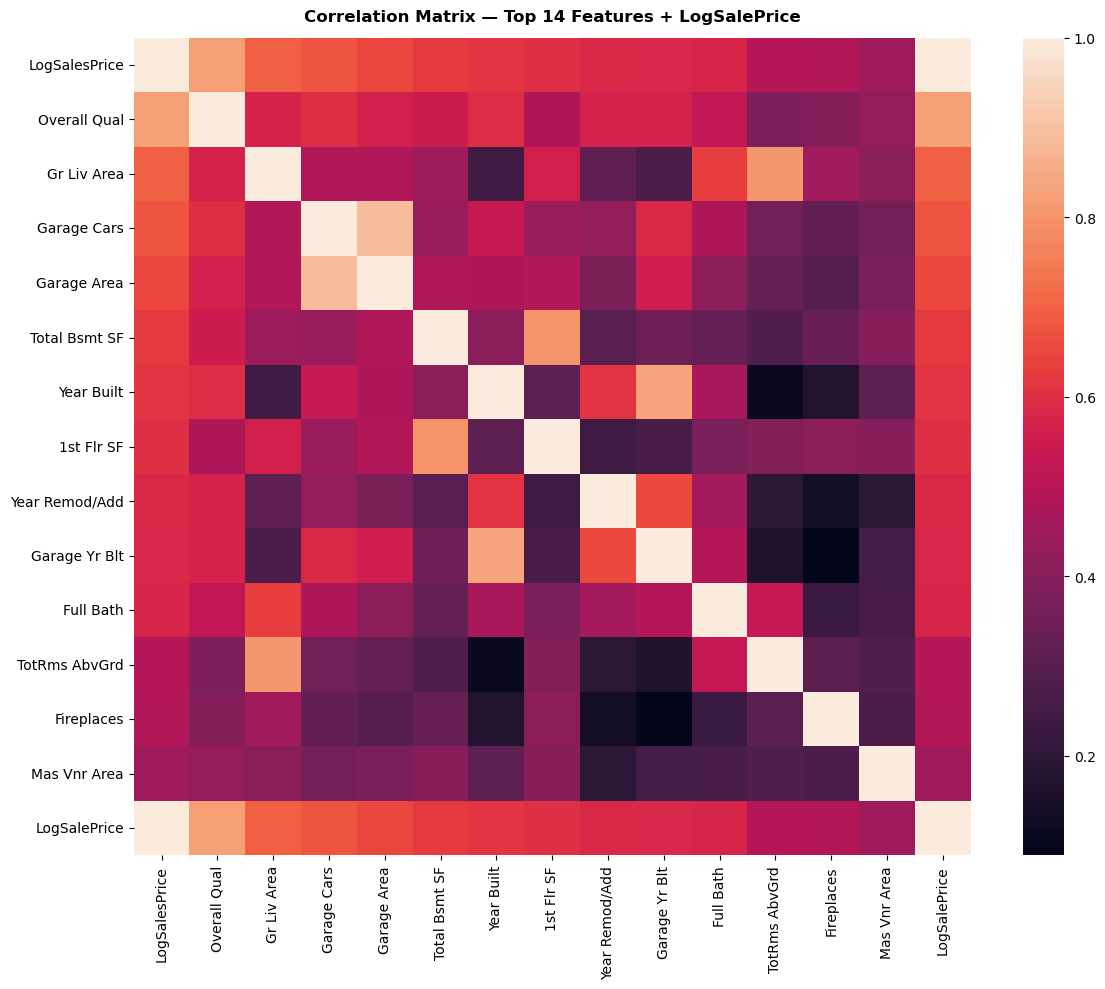

In [23]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr,  fmt=".2f", ax=ax)
ax.set_title("Correlation Matrix — Top 14 Features + LogSalePrice",
             fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

In [24]:
# Showing top 5 features
print("\nTop 5 features correlated with log(SalePrice):")
print(numeric_df.corr()["LogSalePrice"].drop("LogSalePrice")
                .sort_values(ascending=False).head().round(3).to_string())


Top 5 features correlated with log(SalePrice):
LogSalesPrice    1.000
Overall Qual     0.826
Gr Liv Area      0.696
Garage Cars      0.675
Garage Area      0.651
